<strong>Introduction to Healpy</strong>.
J.A.Rubino-Martin - October 2025.

HEALPix is an acronym for Hierarchical Equal Area isoLatitude Pixelization of a sphere.
Please acknowledge HEALPix by quoting the web page (http://healpix.sourceforge.net) and by citing Gorski et al., 2005, ApJ., 622, 759.

Healpy: See tutorial at https://healpy.readthedocs.io/en/latest/index.html

Key properties of the Healpix pixelization:
1) The sphere is hierarchically tessellated into curvilinear quadrilaterals. The lowest resolution partition is comprised of 12 base pixels. Resolution of the tessellation increases by division of each pixel into four new ones. 

2) Areas of all pixels at a given resolution are identical. 

3) Pixels are distributed on lines of constant latitude. This property is essential for all harmonic analysis applications (speed up computing time).

In [54]:
# Loading basic packages
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt

REFERENCE 12 PIXELS

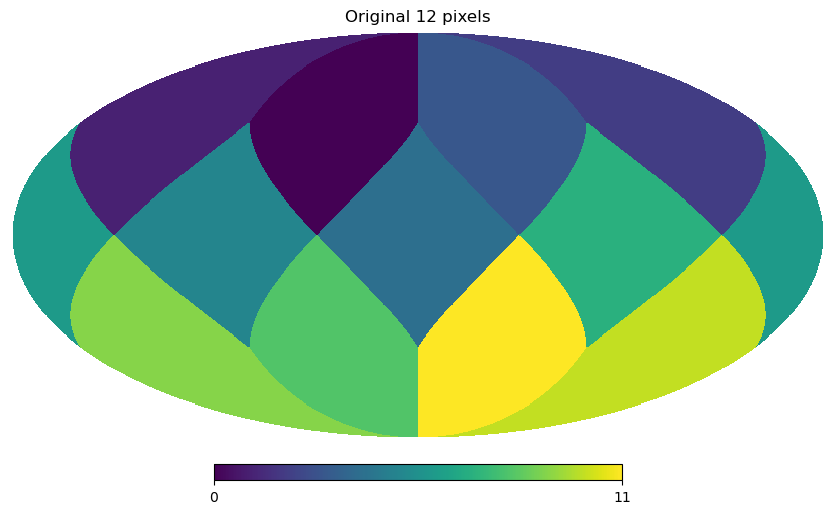

In [55]:
# Display the 12 reference Healpix pixels
basepix = np.arange(12)
hp.mollview(basepix,title="Original 12 pixels")

In [56]:
# NSIDE values are always powers of 2. Number of divisions of the original pixel.
k=1
NSIDE=2**k
NPIX = hp.nside2npix(NSIDE) # = 12 * NSIDE**2
print(' For k={} divisions of the original pixel, I have nside={} and npix={}'.format(k,NSIDE,NPIX))


 For k=1 divisions of the original pixel, I have nside=2 and npix=48


PIXELIZATION SCHEMES: RING and NESTED

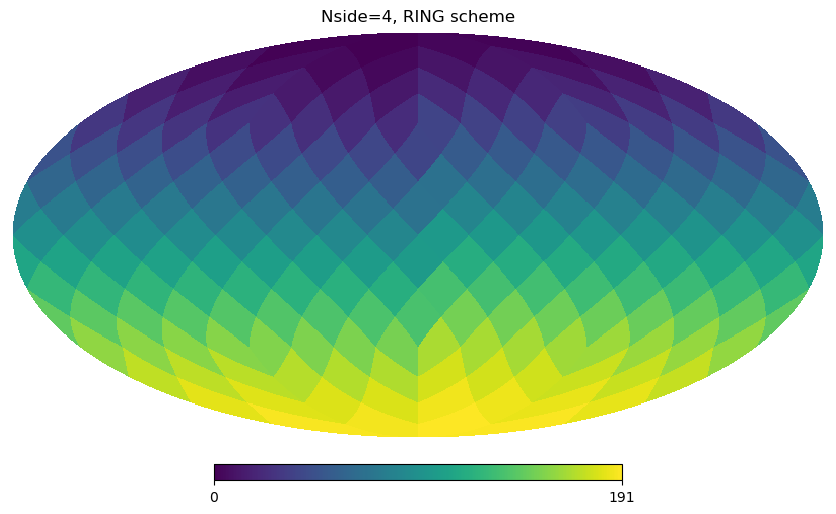

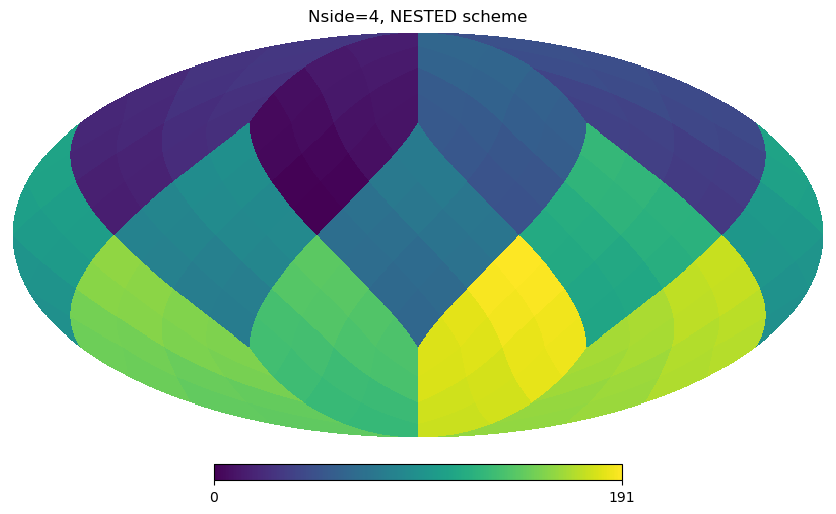

In [57]:
# Pixelization schemes: RING and NESTED
nside = 4
npix  = hp.nside2npix(nside)
map   = np.arange(npix)

hp.mollview(map, title="Nside=4, RING scheme")
hp.mollview(map, title="Nside=4, NESTED scheme", nest=True)

PIXEL PROPERTIES: SIZE AND SOLID ANGLE

In [58]:
# Pixel size and solid angles. Key idea: equal-area pixelization.
NSIDE = 512
NPIX = hp.nside2npix(NSIDE)
print('Number of pixels for NSIDE={} is Npix={}'.format(NSIDE, NPIX))
reso = hp.nside2resol(NSIDE, arcmin=True) # in deg
print("Approximate resolution at NSIDE={} is {:.2} deg (= {:.2} arcmin)".format(NSIDE,  reso/60, reso))
omegapix = 4*np.pi/NPIX
print('Omega_pix (sr) = ',omegapix)

Number of pixels for NSIDE=512 is Npix=3145728
Approximate resolution at NSIDE=512 is 0.11 deg (= 6.9 arcmin)
Omega_pix (sr) =  3.994741635118857e-06


<strong>VISUALIZATION OF RADIO AND MICROWAVE MAPS.</strong>

Downloading data from LAMBDA: https://lambda.gsfc.nasa.gov/

Example using WMAP 9year data.


/bin/bash: wget: command not found


/Users/jalberto/opt/anaconda3/envs/healpix/lib/python3.7/site-packages/healpy/fitsfunc.py:369: UserWarning: If you are not specifying the input dtype and using the default np.float64 dtype of read_map(), please consider that it will change in a future version to None as to keep the same dtype of the input file: please explicitly set the dtype if it is important to you.
  "If you are not specifying the input dtype and using the default "
/Users/jalberto/opt/anaconda3/envs/healpix/lib/python3.7/site-packages/healpy/fitsfunc.py:391: UserWarning: NSIDE = 512
  warnings.warn("NSIDE = {0:d}".format(nside))
/Users/jalberto/opt/anaconda3/envs/healpix/lib/python3.7/site-packages/healpy/fitsfunc.py:400: UserWarning: ORDERING = NESTED in fits file
  warnings.warn("ORDERING = {0:s} in fits file".format(ordering))
/Users/jalberto/opt/anaconda3/envs/healpix/lib/python3.7/site-packages/healpy/fitsfunc.py:426: UserWarning: No INDXSCHM keyword in header file : assume IMPLICIT
  warnings.warn("No INDXSC

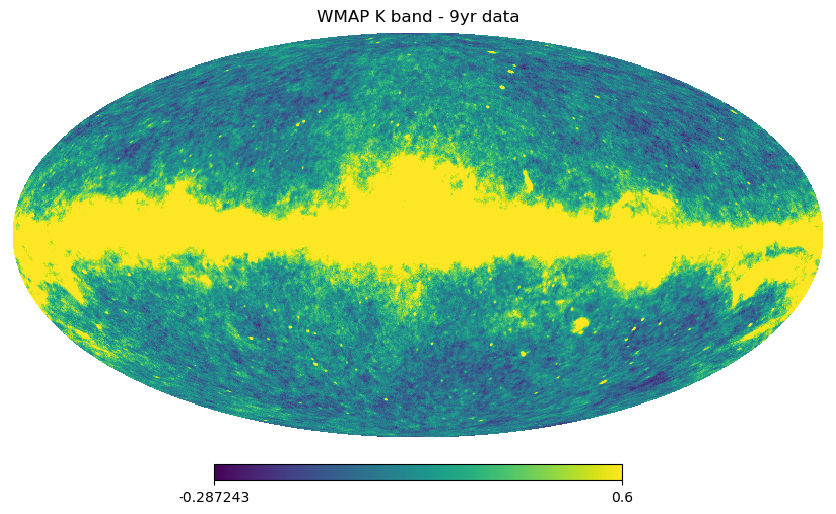

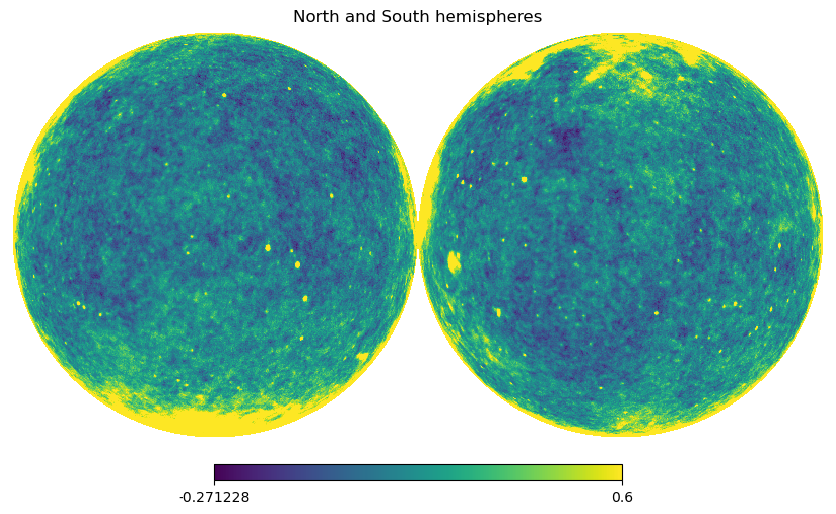

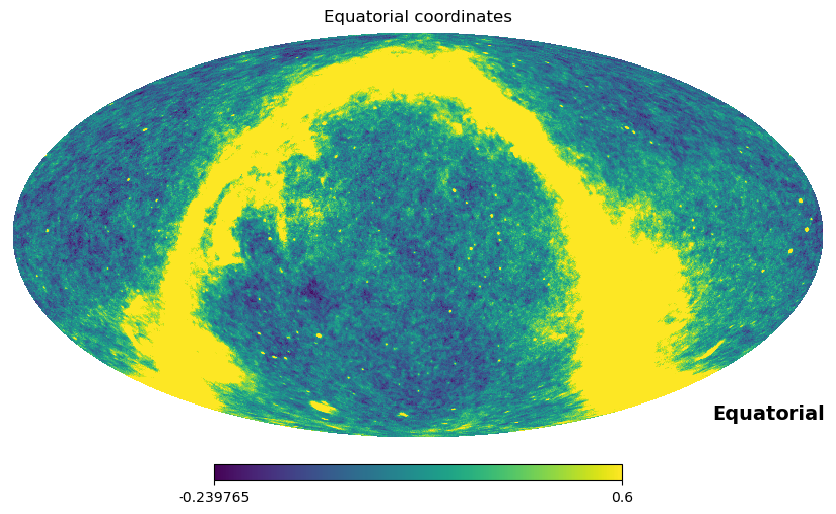

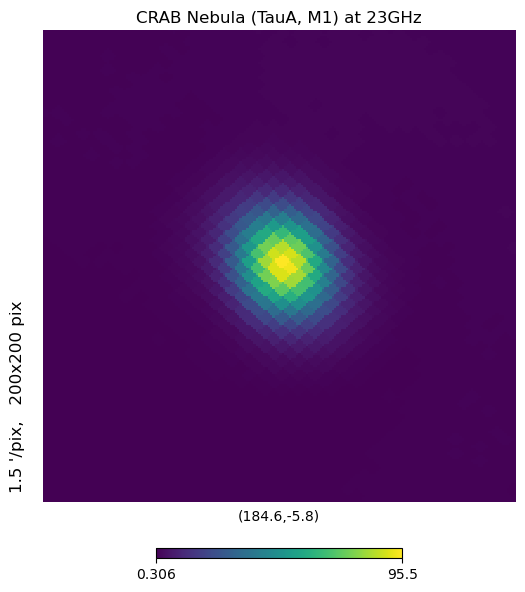

In [59]:
# Downloading data from LAMBDA. (https://lambda.gsfc.nasa.gov/)
!wget -O wmap_band_iqumap_r9_9yr_K_v5.fits "https://lambda.gsfc.nasa.gov/data/map/dr5/skymaps/9yr/raw/wmap_band_iqumap_r9_9yr_K_v5.fits"

map = hp.read_map("wmap_band_iqumap_r9_9yr_K_v5.fits",nest=True)
hp.mollview(map, nest=True, max=0.6,title="WMAP K band - 9yr data")

# Centering the map in other position
hp.orthview(map, nest=True, max=0.6, title="North and South hemispheres", rot=[0,90])

# Change from Galactic to Equatorial coordinates
hp.mollview(map, max=0.6, nest=True, title="Equatorial coordinates", coord=["G","C"])

# Gnomview. Tau A
hp.gnomview(map, nest=True, rot=[184.6, -5.8],title="CRAB Nebula (TauA, M1) at 23GHz")


<strong>MASKING</strong>

/Users/jalberto/opt/anaconda3/envs/healpix/lib/python3.7/site-packages/ipykernel_launcher.py:21: DeprecationWarning: `np.bool` is a deprecated alias for the builtin `bool`. To silence this warning, use `bool` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.bool_` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations


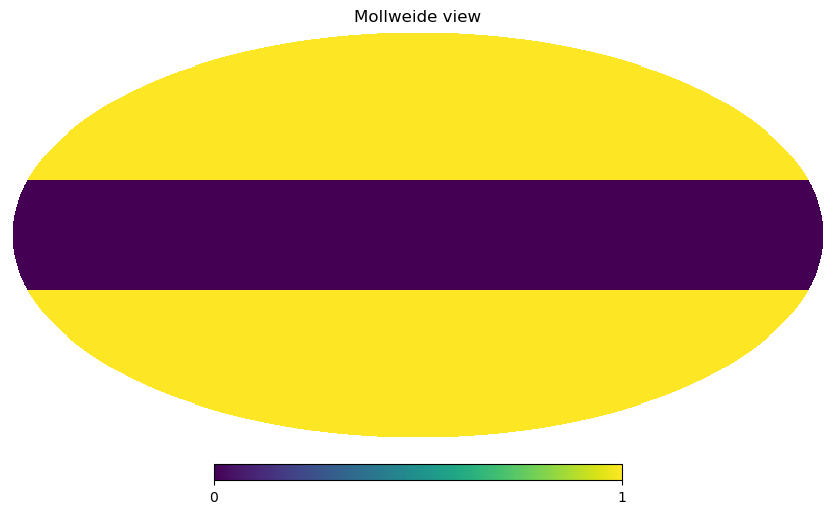

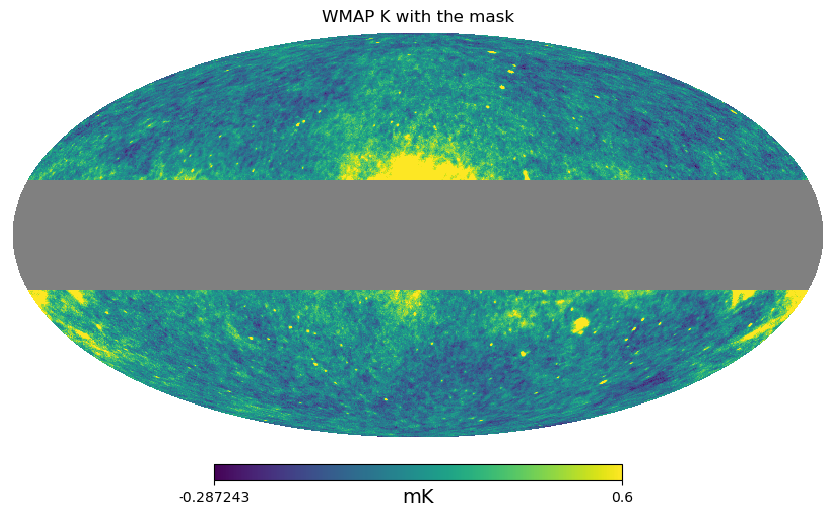

In [60]:
# Generate a mask which excludes the Galactic plane with the
# criteria |b| < 20.0, in NESTED scheme, nside=512
d2r = np.pi/180.0
r2d = 1./d2r
nside = 512
npix  = hp.nside2npix(nside)

ipix  = np.arange(npix)
theta, phi = hp.pix2ang(nside,ipix, nest=True)

gl = phi * r2d
gb = (np.pi/2. - theta) * r2d

# Mask
masc      = np.ones(npix)
cut       = np.where(abs(gb) < 20.0)
masc[cut] = 0.0
hp.mollview(masc,nest=True)

# Masking WMAP data
mask = masc.astype(np.bool)
wmap_map_masked = hp.ma(map)
wmap_map_masked.mask = np.logical_not(mask)

hp.mollview( wmap_map_masked, nest=True, max=0.6, title="WMAP K with the mask",unit="mK")